#Week 2
#Deep Learning with PyTorch
###Neural Network in PyTorch
Implement a feed-forward neural network in PyTorch, covering tensors, datasets,
dataloaders, and loss functions.


# PyTorch setup


In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("GPU Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cu128
Torchvision Version: 0.26.0+cu128
GPU Available: True


# Load Dataset

In [ ]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.42MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.20MB/s]

Training samples: 60000
Testing samples: 10000


## 2.1.1 Dataset Exploration

The MNIST dataset contains handwritten digit images from 0 to 9.
The dataset is divided into training and testing sets.
Before building the neural network, we inspect the image shape, labels, and sample images.

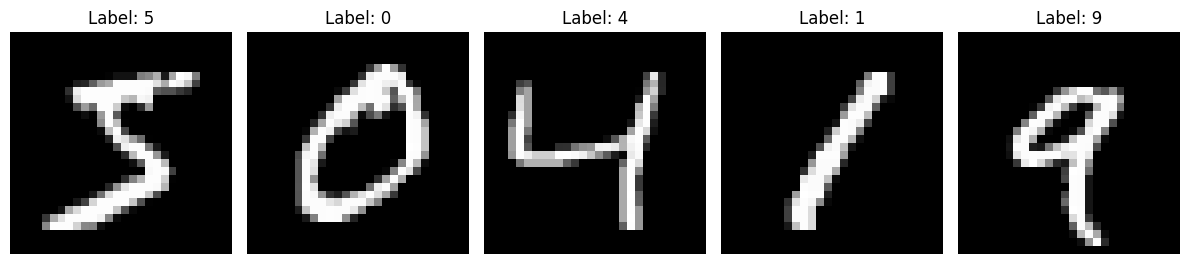

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2.1.2 Sample Image Visualization

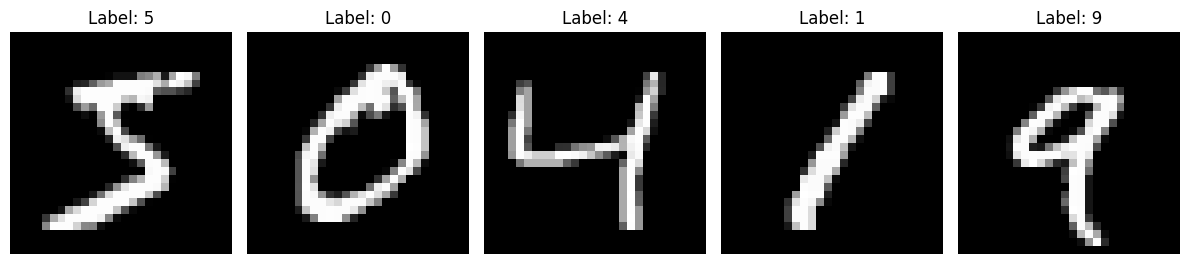

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2.1.3 Creating DataLoaders

In [ ]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 938
Testing batches: 157


In [ ]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])


## 2.1.4 Train-Validation Split

The training dataset is divided into training and validation sets. The validation set is used to monitor model performance during training while keeping the test dataset separate for final evaluation.

In [ ]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size

train_subset, val_subset = random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Testing samples:", len(test_data))

Training samples: 54000
Validation samples: 6000
Testing samples: 10000


## 2.1.5 Build the Feed-Forward Neural Network

A feed-forward neural network is created using PyTorch. The MNIST images are flattened from 28×28 pixels into 784 input features. The network contains fully connected layers with ReLU activation functions and produces 10 output classes representing digits from 0 to 9.

In [ ]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


## 2.1.6 Define Loss Function and Optimizer

Cross-Entropy Loss is used because this is a multi-class classification problem. The Adam optimizer is used to update the model parameters during training.

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss Function:", loss_function)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 2.1.7 Train the Neural Network

The neural network is trained using a training loop. In each epoch, the model performs a forward pass, calculates the loss, performs backpropagation, and updates its parameters using the Adam optimizer. Training and validation loss are recorded to monitor model performance.

In [ ]:
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Training Loss: {train_loss:.4f} "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch [1/5] Training Loss: 0.3475 Validation Loss: 0.1904
Epoch [2/5] Training Loss: 0.1454 Validation Loss: 0.1416
Epoch [3/5] Training Loss: 0.0976 Validation Loss: 0.1150
Epoch [4/5] Training Loss: 0.0742 Validation Loss: 0.1148
Epoch [5/5] Training Loss: 0.0583 Validation Loss: 0.1034


## 2.1.7 Train the Neural Network

The neural network is trained using a training loop. Training and validation loss are recorded for each epoch to monitor model performance.

In [ ]:
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Training Loss: {train_loss:.4f} "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch [1/5] Training Loss: 0.0452 Validation Loss: 0.0942
Epoch [2/5] Training Loss: 0.0370 Validation Loss: 0.1080
Epoch [3/5] Training Loss: 0.0307 Validation Loss: 0.0945
Epoch [4/5] Training Loss: 0.0252 Validation Loss: 0.0917
Epoch [5/5] Training Loss: 0.0222 Validation Loss: 0.0934


## 2.1.8 Training and Validation Loss

The training and validation loss curves are visualized to observe how the model learns over the training epochs.

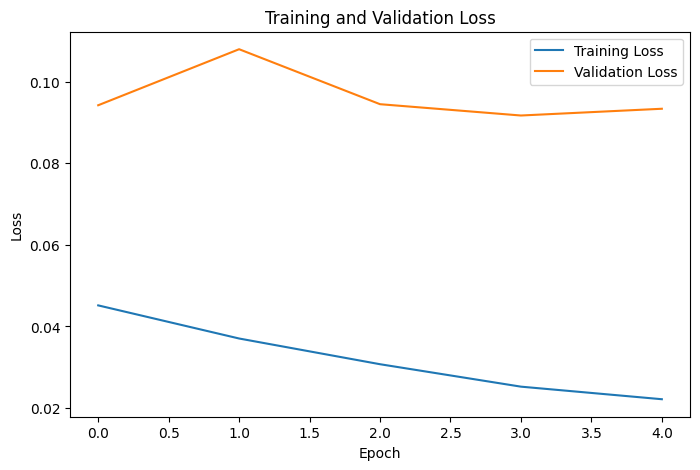

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## 2.1.9 Evaluate Model Accuracy

The trained model is evaluated on the validation and test datasets using classification accuracy.

In [ ]:
def calculate_accuracy(data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)
test_accuracy = calculate_accuracy(test_loader)

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 99.51%
Validation Accuracy: 97.48%
Test Accuracy: 97.63%


## 2.1.10 Sample Predictions

Sample test images are passed through the trained neural network and the predicted labels are compared with the actual labels.

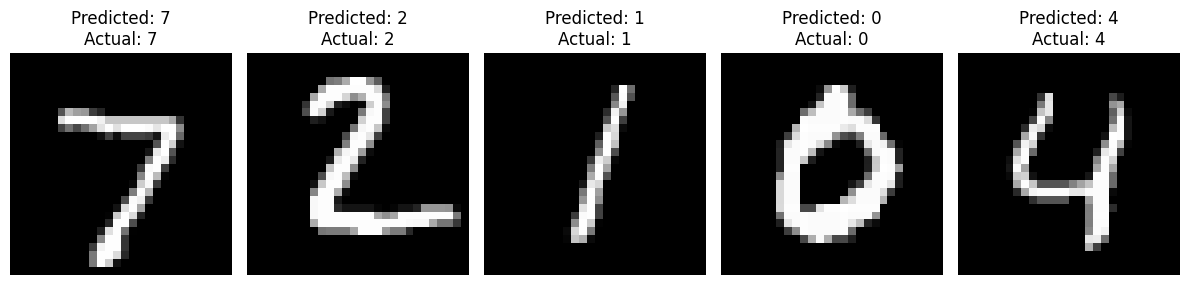

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(
        f"Predicted: {predictions[i].item()}\nActual: {labels[i].item()}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2.1.11 Model Evaluation Summary

The model performance is summarized using training, validation, and test accuracy. The loss curves and sample predictions provide additional insight into the model's learning behavior and classification performance.

In [ ]:
print("Model Evaluation Summary")
print("-----------------------")
print(f"Training Accuracy:   {train_accuracy:.2f}%")
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Test Accuracy:       {test_accuracy:.2f}%")

Model Evaluation Summary
-----------------------
Training Accuracy:   99.51%
Validation Accuracy: 97.48%
Test Accuracy:       97.63%


## 2.1.12 Save the Trained Model

The trained PyTorch model is saved so that it can be reused later without retraining from scratch.

In [ ]:
torch.save(model.state_dict(), "mnist_feedforward_model.pth")

print("Model saved successfully as mnist_feedforward_model.pth")

Model saved successfully as mnist_feedforward_model.pth


## 2.1.13 Conclusion

A feed-forward neural network was successfully implemented using PyTorch for MNIST digit classification. The workflow included dataset preparation, train-validation splitting, DataLoaders, model architecture, loss function, optimizer, training loop, validation, test evaluation, and sample predictions. The model was also saved for future use.